# 9주차: 실시간 자연어 처리 및 실무 응용 (2026-06-02)

In [21]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from config import CONTENT_DIR
import platform

from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from sklearn.decomposition import PCA

from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from tqdm import tqdm
import re
import yfinance as yf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

warnings.filterwarnings('ignore')

# 한글 폰트 설정 (OS 환경별 대응)
if platform.system() == 'Darwin':  # macOS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':  # Windows
    plt.rc('font', family='Malgun Gothic')
else:  # Linux (Ubuntu, Colab 등)
    plt.rc('font', family='NanumGothic')

plt.rc('axes', unicode_minus=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

print("환경 설정 완료!")

device: cpu
환경 설정 완료!


In [2]:
base_sentences = [
    '고객 배송 빠르다 만족하다',
    '사용자 배송 빠르다 칭찬하다',
    '리뷰 배송 신속하다 만족하다',
    '고객 택배 신속하다 만족하다',
    '사용자 택배 빠르다 칭찬하다',
    '고객 배송 느리다 불만이다',
    '사용자 택배 지연되다 불만이다',
    '리뷰 배송 느리다 불평하다',
    '고객 환불 지연되다 불만이다',
    '사용자 교환 지연되다 불평하다',
    '상품 품질 좋다 만족하다',
    '제품 품질 뛰어나다 칭찬하다',
    '상품 성능 좋다 만족하다',
    '제품 성능 뛰어나다 추천하다',
    '가격 저렴하다 만족하다',
    '가격 합리적이다 추천하다',
    '결제 오류 발생하다 불만이다',
    '로그인 오류 발생하다 불편하다',
    '앱 오류 잦다 불편하다',
    '고객센터 친절하다 만족하다',
    '상담원 친절하다 칭찬하다',
    '고객센터 응답 빠르다 만족하다',
]

# 토큰화(빈칸을 기준으로)
tokenized_sentences = [sentence.split() for sentence in base_sentences]

# 예제 문장이 너무 적으면 단어쌍이 충분히 반복되지 않아 임베딩이 불안정할 수 있음
# 같은 문장을 40번 반복.
train_sentences = tokenized_sentences * 40

#
random.shuffle(train_sentences)

print('문장 수:', len(train_sentences))
print('예시 문장:', train_sentences[:3])

문장 수: 880
예시 문장: [['리뷰', '배송', '느리다', '불평하다'], ['고객', '배송', '빠르다', '만족하다'], ['가격', '저렴하다', '만족하다']]


어휘 수: 36
임베딩 행렬 크기: (36, 50)
  token  count
0  만족하다    320
1    배송    200
2  불만이다    160
3  칭찬하다    160
4   사용자    160
5   빠르다    160
6    고객    160
7    택배    120
8    오류    120
9  지연되다    120
배송 벡터 차원: (50,)
[ 0.29144058 -0.35060537 -0.18489751  0.07447591  0.41220954 -0.18590148
 -0.3270932   0.42981717  0.1386879   0.15445112]
[배송]와 가까운 단어
    신속하다  0.791
    불평하다  0.786
      리뷰  0.773
      고객  0.772
     느리다  0.741

[만족하다]와 가까운 단어
      상품  0.656
      응답  0.614
      좋다  0.567
    고객센터  0.567
    신속하다  0.552

[오류]와 가까운 단어
     로그인  0.923
    불편하다  0.910
    발생하다  0.885
      잦다  0.865
      결제  0.863
    단어1   단어2  cosine_similarity
0    배송    택배           0.732565
1   빠르다  신속하다           0.708005
3  불만이다  불편하다           0.560179
2  만족하다  칭찬하다           0.468576
4    배송    오류           0.234952
  기준 단어        CBOW top3  Skip-gram top3
0    배송   신속하다, 불평하다, 리뷰  리뷰, 불평하다, 신속하다
1  만족하다       상품, 응답, 좋다    상품, 응답, 고객센터
2    오류  로그인, 불편하다, 발생하다   불편하다, 로그인, 잦다


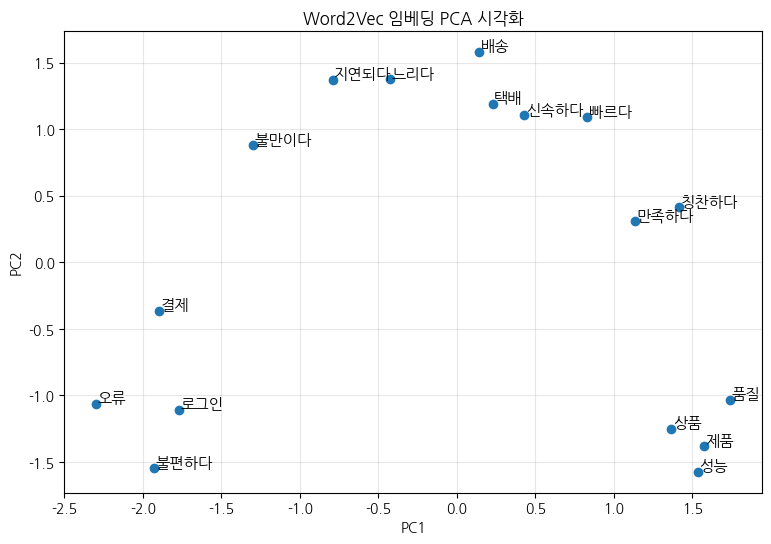

In [5]:
cbow_model = Word2Vec(
    sentences=train_sentences,
    vector_size=50,
    window=2,
    min_count=1,
    workers=1,
    sg=0,
    seed=SEED,
    epochs=100,
)

print('어휘 수:', len(cbow_model.wv))
print('임베딩 행렬 크기:', cbow_model.wv.vectors.shape)

vocab = cbow_model.wv.index_to_key
print(pd.DataFrame({
    'token': vocab,
    'count': [cbow_model.wv.get_vecattr(token, 'count') for token in vocab],
}).head(10))

word = '배송'
vector = cbow_model.wv[word]

print(word, '벡터 차원:', vector.shape)
print(vector[:10])

def show_similar(model, word, topn=5):
    print(f'[{word}]와 가까운 단어')
    for token, score in model.wv.most_similar(word, topn=topn):
        print(f'{token:>8s}  {score:.3f}')

show_similar(cbow_model, '배송')
print()
show_similar(cbow_model, '만족하다')
print()
show_similar(cbow_model, '오류')

pairs = [
    ('배송', '택배'),
    ('빠르다', '신속하다'),
    ('만족하다', '칭찬하다'),
    ('불만이다', '불편하다'),
    ('배송', '오류'),
]

print(pd.DataFrame(
    [(a, b, cbow_model.wv.similarity(a, b)) for a, b in pairs],
    columns=['단어1', '단어2', 'cosine_similarity'],
).sort_values('cosine_similarity', ascending=False))

skipgram_model = Word2Vec(
    sentences=train_sentences,
    vector_size=50,
    window=2,
    min_count=1,
    workers=1,
    sg=1,
    seed=SEED,
    epochs=100,
)

comparison = []
for target in ['배송', '만족하다', '오류']:
    cbow_top = ', '.join([w for w, _ in cbow_model.wv.most_similar(target, topn=3)])
    sg_top = ', '.join([w for w, _ in skipgram_model.wv.most_similar(target, topn=3)])
    comparison.append((target, cbow_top, sg_top))

print(pd.DataFrame(comparison, columns=['기준 단어', 'CBOW top3', 'Skip-gram top3']))

selected_words = [
    '배송', '택배', '빠르다', '신속하다', '느리다', '지연되다',
    '만족하다', '칭찬하다', '불만이다', '불편하다',
    '상품', '제품', '품질', '성능', '오류', '결제', '로그인',
]

vectors = np.array([cbow_model.wv[word] for word in selected_words])
points = PCA(n_components=2, random_state=SEED).fit_transform(vectors)

plt.figure(figsize=(9, 6))
plt.scatter(points[:, 0], points[:, 1])

for word, (x, y) in zip(selected_words, points):
    plt.text(x + 0.01, y + 0.01, word, fontsize=11)

plt.title('Word2Vec 임베딩 PCA 시각화')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)
plt.show()


전체 문자 수: 6559
문자 어휘 크기: 62
어휘 일부: ['\n', ' ', '.', '가', '객', '검', '결', '고', '기', '는', '능', '늦', '다', '데', '때', '렵', '류', '르', '리', '말', '면', '문', '배', '불', '뷰', '빠', '사', '상', '색', '센']
입력 shape: torch.Size([64, 24])
정답 shape: torch.Size([64, 24])
입력 예시:  때문에 주문을 취소했다.
사용자는 쿠폰 혜
정답 예시: 때문에 주문을 취소했다.
사용자는 쿠폰 혜택
CharRNNLM(
  (embedding): Embedding(62, 32)
  (rnn): RNN(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=62, bias=True)
)
Epoch 01 | loss: 1.1324
Epoch 02 | loss: 0.1440
Epoch 03 | loss: 0.0969
Epoch 04 | loss: 0.0877
Epoch 05 | loss: 0.0831
Epoch 06 | loss: 0.0789
Epoch 07 | loss: 0.0765
Epoch 08 | loss: 0.0749
Epoch 09 | loss: 0.0745
Epoch 10 | loss: 0.0730
Epoch 11 | loss: 0.0706
Epoch 12 | loss: 0.0697
Epoch 13 | loss: 0.0693
Epoch 14 | loss: 0.0689
Epoch 15 | loss: 0.0684


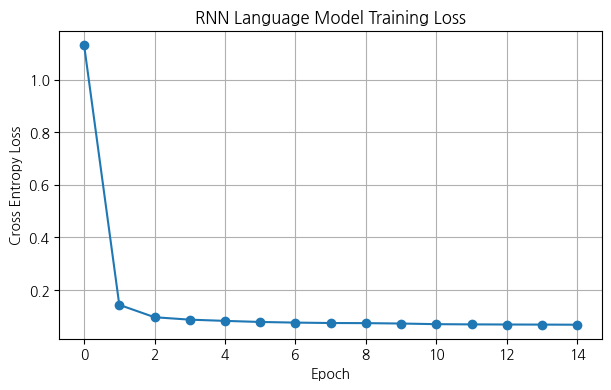

고객은 배송이 빠르다고 말했다.
고객은 배송이 늦다고 말했다.
리뷰는 상품 품질이 좋다고 평가했다.
리뷰는 고객센터 연결이 어렵다고 평가했다.
사용자는 결제 오류 때문에 주문을 취소했


In [10]:
sentences = [
    "고객은 배송이 빠르다고 말했다.",
    "고객은 배송이 늦다고 말했다.",
    "리뷰는 상품 품질이 좋다고 평가했다.",
    "리뷰는 고객센터 연결이 어렵다고 평가했다.",
    "사용자는 결제 오류 때문에 주문을 취소했다.",
    "사용자는 쿠폰 혜택 때문에 다시 주문했다.",
    "앱 업데이트 이후 화면이 불편하다.",
    "앱 검색 기능이 편리하다.",
]

text = "\n".join(sentences * 40)
chars = sorted(set(text))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

encoded = torch.tensor([stoi[ch] for ch in text], dtype=torch.long)
vocab_size = len(chars)

print("전체 문자 수:", len(encoded))
print("문자 어휘 크기:", vocab_size)
print("어휘 일부:", chars[:30])

block_size = 24

class CharDataset(Dataset):
    def __init__(self, data, block_size):
        self.data = data
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        chunk = self.data[idx:idx + self.block_size + 1]
        x = chunk[:-1]
        y = chunk[1:]
        return x, y

dataset = CharDataset(encoded, block_size)
loader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=True)

xb, yb = next(iter(loader))
print("입력 shape:", xb.shape)
print("정답 shape:", yb.shape)
print("입력 예시:", "".join(itos[int(i)] for i in xb[0]))
print("정답 예시:", "".join(itos[int(i)] for i in yb[0]))

class CharRNNLM(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embedding(x)
        out, hidden = self.rnn(emb, hidden)
        logits = self.fc(out)
        return logits, hidden

model = CharRNNLM(vocab_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

print(model)

epochs = 15
losses = []

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits, _ = model(x_batch)
        loss = criterion(logits.reshape(-1, vocab_size), y_batch.reshape(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch:02d} | loss: {avg_loss:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(losses, marker="o")
plt.title("RNN Language Model Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.grid(True)
plt.show()

def generate_text(model, start="고객", max_new_chars=80, temperature=0.8):
    model.eval()
    ids = [stoi.get(ch, 0) for ch in start]
    x = torch.tensor([ids], dtype=torch.long, device=device)

    with torch.no_grad():
        for _ in range(max_new_chars):
            x_cond = x[:, -block_size:]
            logits, _ = model(x_cond)
            logits = logits[:, -1, :] / temperature
            probs = torch.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            x = torch.cat([x, next_id], dim=1)

    return "".join(itos[int(i)] for i in x[0].cpu())

print(generate_text(model, start="고객", max_new_chars=100, temperature=0.8))

In [13]:
data = "나라의 말이 중국과 달라 문자와 서로 통하지 아니하기에 이런 까닭으로 어리석은 백성이 이르고자 할 바가 있어도 마침내 제 뜻을 능히 펴지 못할 사람이 많으니라 내가 이를 위해 가엾이 여겨 새로 스물여덟 글자를 만드노니 사람마다 하여 쉬이 익혀 날로 씀에 편안케 하고자 할 따름이니라"
#데이터를 preprocessing 해주는 부분입니다
#RNN과 동일한 방법입니다
def data_preprocessing(data):
    data = re.sub('[^가-힣]', ' ', data)
    tokens = data.split()
    vocab = list(set(tokens))
    vocab_size = len(vocab)

    Word_to_ix = {Word: i for i, Word in enumerate(vocab)}
    ix_to_Word = {i: Word for i, Word in enumerate(vocab)}

    return tokens, vocab_size, Word_to_ix, ix_to_Word

# 활성화 함수
def sigmoid(input):
    return 1 / (1 + np.exp(-input))

def sigmoid_derivative(input):
    return input * (1 - input)

def tanh(input, derivative=False):
    return np.tanh(input)

def tanh_derivative(input):
    return 1 - input ** 2

def softmax(input):
    return np.exp(input) / np.sum(np.exp(input))

class LSTM:
    def __init__(self, input_size, hidden_size, output_size, num_epochs, learning_rate):
        # Hyperparameters
        self.learning_rate = learning_rate
        self.hidden_size = hidden_size
        self.num_epochs = num_epochs

        # Forget Gate
        self.Wf = np.random.randn(hidden_size, input_size)*0.1
        self.bf = np.zeros((hidden_size, 1))

        # Input Gate
        self.Wi = np.random.randn(hidden_size, input_size)*0.1
        self.bi = np.zeros((hidden_size, 1))

        # Candidate Gate
        self.Wc = np.random.randn(hidden_size, input_size)*0.1
        self.bc = np.zeros((hidden_size, 1))

        # Output Gate
        self.Wo = np.random.randn(hidden_size, input_size)*0.1
        self.bo = np.zeros((hidden_size, 1))

        # Final Gate
        self.Wy = np.random.randn(output_size, hidden_size)
        self.by = np.zeros((output_size, 1))

    # 네트워크 메모리 리셋
    def reset(self):
        self.X = {}

        self.HS = {-1: np.zeros((self.hidden_size, 1))}
        self.CS = {-1: np.zeros((self.hidden_size, 1))}

        self.C = {}
        self.O = {}
        self.F = {}
        self.I = {}
        self.outputs = {}

    # Forward 순전파
    def forward(self, inputs):
        # self.reset()
        x = {}
        outputs = []
        for t in range(len(inputs)):
            x[t] = np.zeros((vocab_size , 1))
            x[t][inputs[t]] = 1  # 각각의 Word에 대한 one hot coding
            self.X[t] = np.concatenate((self.HS[t - 1], x[t]))

            self.F[t] = sigmoid(np.dot(self.Wf, self.X[t]) + self.bf)
            self.I[t] = sigmoid(np.dot(self.Wi, self.X[t]) + self.bi)
            self.C[t] = tanh(np.dot(self.Wc, self.X[t]) + self.bc)
            self.O[t] = sigmoid(np.dot(self.Wo, self.X[t]) + self.bo)

            self.CS[t] = self.F[t] * self.CS[t - 1] + self.I[t] * self.C[t]
            self.HS[t] = self.O[t] * tanh(self.CS[t])

            outputs += [np.dot(self.Wy, self.HS[t]) + self.by]

        return outputs

    # 역전파
    def backward(self, errors, inputs):
        dLdWf, dLdbf = 0, 0
        dLdWi, dLdbi = 0, 0
        dLdWc, dLdbc = 0, 0
        dLdWo, dLdbo = 0, 0
        dLdWy, dLdby = 0, 0

        dh_next, dc_next = np.zeros_like(self.HS[0]), np.zeros_like(self.CS[0])
        for t in reversed(range(len(inputs))):
            error = errors[t]

            # Final Gate Weights and Biases Errors
            dLdWy += np.dot(error, self.HS[t].T)         #𝜕𝐿/𝜕𝑊𝑦
            dLdby += error                               #𝜕𝐿/𝜕b𝑦 = (𝜕𝐿/𝜕z_t)(𝜕z_t/𝜕b𝑦) = error x 1 (Zt = WyHSt + by)

            # Hidden State Error
            dLdHS = np.dot(self.Wy.T, error) + dh_next    #𝜕𝐿/𝜕𝐻𝑆

            # Output Gate Weights and Biases Errors
            dLdo = tanh(self.CS[t]) * dLdHS * sigmoid_derivative(self.O[t])
            dLdWo += np.dot(dLdo, inputs[t].T)
            dLdbo += dLdo

            # Cell State Error
            dLdCS = tanh_derivative(tanh(self.CS[t])) * self.O[t] * dLdHS + dc_next

            # Forget Gate Weights and Biases Errors
            dLdf = dLdCS * self.CS[t - 1] * sigmoid_derivative(self.F[t])
            dLdWf += np.dot(dLdf, inputs[t].T)
            dLdbf += dLdf

            # Input Gate Weights and Biases Errors
            dLdi = dLdCS * self.C[t] * sigmoid_derivative(self.I[t])
            dLdWi += np.dot(dLdi, inputs[t].T)
            dLdbi += dLdi

            # Candidate Gate Weights and Biases Errors
            dLdc = dLdCS * self.I[t] * tanh_derivative(self.C[t])
            dLdWc += np.dot(dLdc, inputs[t].T)
            dLdbc += dLdc

            # Concatenated Input Error (Sum of Error at Each Gate!)
            d_z = np.dot(self.Wf.T, dLdf) + np.dot(self.Wi.T, dLdi) + np.dot(self.Wc.T, dLdc) + np.dot(self.Wo.T, dLdo)

            # Error of Hidden State and Cell State at Next Time Step
            dh_next = d_z[:self.hidden_size, :]
            dc_next = self.F[t] * dLdCS

        for d_ in (dLdWf, dLdbf, dLdWi, dLdbi, dLdWc, dLdbc, dLdWo, dLdbo, dLdWy, dLdby):
            np.clip(d_, -1, 1, out=d_)

        self.Wf += dLdWf * self.learning_rate * (-1)
        self.bf += dLdbf * self.learning_rate * (-1)

        self.Wi += dLdWi * self.learning_rate * (-1)
        self.bi += dLdbi * self.learning_rate * (-1)

        self.Wc += dLdWc * self.learning_rate * (-1)
        self.bc += dLdbc * self.learning_rate * (-1)

        self.Wo += dLdWo * self.learning_rate * (-1)
        self.bo += dLdbo * self.learning_rate * (-1)

        self.Wy += dLdWy * self.learning_rate * (-1)
        self.by += dLdby * self.learning_rate * (-1)

    # Train
    def train(self, inputs, labels):
        for _ in tqdm(range(self.num_epochs)):
            self.reset()
            input_idx = [Word_to_ix[input] for input in inputs]
            predictions = self.forward(input_idx)

            errors = []
            for t in range(len(predictions)):
                errors += [softmax(predictions[t])]
                errors[-1][Word_to_ix[labels[t]]] -= 1

            self.backward(errors, self.X)

    def test(self, inputs, labels):
        accuracy = 0
        probabilities = self.forward([Word_to_ix[input] for input in inputs])

        gt = ''
        output = '나라의 '
        for q in range(len(labels)):
            prediction = ix_to_Word[np.argmax(softmax(probabilities[q].reshape(-1)))]
            gt += inputs[q] + ' '
            output += prediction + ' '

            if prediction == labels[q]:
                accuracy += 1

        print('실제값: ', gt)
        print('예측값: ', output)

hidden_size = 25

# data preparation
tokens, vocab_size, Word_to_ix, ix_to_Word = data_preprocessing(data)
train_X, train_y = tokens[:-1], tokens[1:]

lstm = LSTM(input_size=vocab_size + hidden_size, hidden_size=hidden_size, output_size=vocab_size, num_epochs=1000,
            learning_rate=0.05)

##### Training #####
lstm.train(train_X, train_y)

lstm.test(train_X, train_y)

100%|██████████| 1000/1000 [00:02<00:00, 350.77it/s]

실제값:  나라의 말이 중국과 달라 문자와 서로 통하지 아니하기에 이런 까닭으로 어리석은 백성이 이르고자 할 바가 있어도 마침내 제 뜻을 능히 펴지 못할 사람이 많으니라 내가 이를 위해 가엾이 여겨 새로 스물여덟 글자를 만드노니 사람마다 하여 쉬이 익혀 날로 씀에 편안케 하고자 할 
예측값:  나라의 말이 중국과 달라 문자와 서로 통하지 아니하기에 이런 까닭으로 어리석은 백성이 이르고자 할 바가 있어도 마침내 제 뜻을 능히 펴지 못할 사람이 많으니라 내가 이를 위해 가엾이 여겨 새로 스물여덟 글자를 만드노니 사람마다 하여 쉬이 익혀 날로 씀에 편안케 하고자 할 따름이니라 


In [16]:
tickers = pd.read_csv(CONTENT_DIR / 'nasdaq.csv')

tsmc = yf.download('TSM', start='2025-05-31', end='2026-05-31')   # 최근 1년간 tsmc 주가 데이터
tsmc = tsmc.reset_index()
tsmc.columns = tsmc.columns.droplevel(1)
tsmc.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2025-06-02,192.456314,192.772406,189.848613,190.678332,7447400
1,2025-06-03,195.192444,195.745590,191.271012,191.972332,9548300
2,2025-06-04,199.923828,201.533891,197.928552,198.916318,13531100
3,2025-06-05,200.852341,203.242733,199.805311,202.373509,12214300
4,2025-06-06,202.669830,203.766251,200.743690,201.089414,8532000


In [18]:
pal = yf.Ticker('PLTR')
df1 = pal.history(period='1y')
df1 = pal.history(start='2023-01-01', end='2026-05-31')
df1.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2023-01-03 00:00:00-05:00,6.58,6.640,6.275,6.39,29969900,0.0,0.0
2023-01-04 00:00:00-05:00,6.48,6.675,6.370,6.58,31660500,0.0,0.0
2023-01-05 00:00:00-05:00,6.45,6.490,6.250,6.32,34186000,0.0,0.0
2023-01-06 00:00:00-05:00,6.40,6.450,6.090,6.40,30596400,0.0,0.0
2023-01-09 00:00:00-05:00,6.49,6.670,6.400,6.50,31028900,0.0,0.0


In [19]:
# 캔들 차트로 그리기
import plotly.graph_objects as go
import plotly.express as px

fig = go.Figure(data=[go.Candlestick(x=tsmc['Date'],
                                     open=tsmc['Open'],
                                     high=tsmc['High'],
                                     low=tsmc['Low'],
                                     close=tsmc['Close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

In [20]:
stock = yf.download(tickers['Symbol'].tolist(), start='2025-05-31', end='2026-05-31')
# 2026년 5월 31일 기준으로 1년간 가장 많이 상승(하락) 종목 찾기

stock = stock.reset_index()
starts = stock[stock['Date']=='2025-06-02']['Open'].transpose()
starts = starts.reset_index()

ends = stock[stock['Date']=='2026-05-29']['Close'].transpose()
ends = ends.reset_index()

starts.columns = ['Ticker', 'START']
ends.columns = ['Ticker', 'END']

stocks_ = pd.merge(starts, ends, how='left', left_on='Ticker', right_on='Ticker')
stocks_['rate'] = (stocks_['END'] - stocks_['START']) / stocks_['START']
stocks_ = stocks_.sort_values('rate', ascending=False)

fig = px.bar(stocks_, y='rate', x='Ticker')

volumes = stock['Volume'].sum().reset_index()
volumes.columns = ['Ticker', 'Volume']
volumes = volumes.sort_values('Volume', ascending=False)

fig = px.bar(volumes, y='Volume', x='Ticker')
fig.show()

[*********************100%***********************]  8 of 8 completed


[*********************100%***********************]  1 of 1 completed


Epoch 1/30, Loss : 0.2592
Epoch 2/30, Loss : 0.2267
Epoch 3/30, Loss : 0.1956
Epoch 4/30, Loss : 0.1536
Epoch 5/30, Loss : 0.0978
Epoch 6/30, Loss : 0.0539
Epoch 7/30, Loss : 0.0361
Epoch 8/30, Loss : 0.0191
Epoch 9/30, Loss : 0.0077
Epoch 10/30, Loss : 0.0044
Epoch 11/30, Loss : 0.0039
Epoch 12/30, Loss : 0.0037
Epoch 13/30, Loss : 0.0036
Epoch 14/30, Loss : 0.0035
Epoch 15/30, Loss : 0.0033
Epoch 16/30, Loss : 0.0033
Epoch 17/30, Loss : 0.0031
Epoch 18/30, Loss : 0.0030
Epoch 19/30, Loss : 0.0030
Epoch 20/30, Loss : 0.0029
Epoch 21/30, Loss : 0.0028
Epoch 22/30, Loss : 0.0027
Epoch 23/30, Loss : 0.0027
Epoch 24/30, Loss : 0.0027
Epoch 25/30, Loss : 0.0026
Epoch 26/30, Loss : 0.0026
Epoch 27/30, Loss : 0.0026
Epoch 28/30, Loss : 0.0025
Epoch 29/30, Loss : 0.0025
Epoch 30/30, Loss : 0.0025


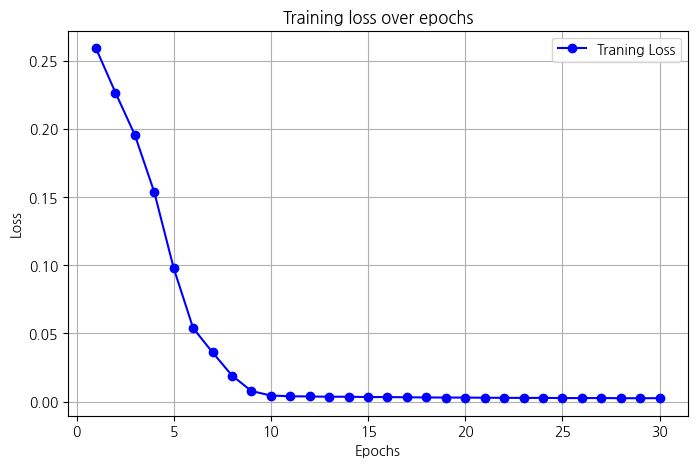

In [22]:
stock = yf.download('035420.KS', start='2021-01-01', end='2026-06-02')
stock = stock.reset_index()

stock.columns = stock.columns.droplevel(1)
# 종가만 사용
close_prices = stock[['Close']]
# 데이터 스케일링
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(close_prices)

# 시퀀스 데이터 생성
# 30일치 종가 흐름을 입력 x로, 그 다음 날 종가를 정답 y로 만드는 슬라이딩 윈도우
sequence_length = 30        # 30일치 
X, y = [], []

for i in range(len(scaled_data) - sequence_length):
    X.append(scaled_data[i:i+sequence_length])
    y.append(scaled_data[i+sequence_length])

X, y = np.array(X), np.array(y)
# 데이터 분할
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
# 텐서 변환
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

# 데이터 로더 생성
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=50, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_layer_size, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    # 순전파 연산
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.linear(lstm_out[:,-1,:])

model = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)
losses = []

# 모델 학습
model.train()
epochs = 30

for epoch in range(epochs):
    epoch_loss = 0  # 한 epoch 동안의 총 loss 저장
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)       # 손실 계산
        loss.backward()         # 역전파 수행
        optimizer.step()        # 가중치 업데이트
        epoch_loss += loss.item()       # 현재 배치의 손실값을 epoch_loss에 추가

    # 평균 loss
    avg_loss = epoch_loss / len(train_loader)       # 배치 개수로 나누어 평균 손실 계산
    losses.append(avg_loss)

    print(f'Epoch {epoch+1}/{epochs}, Loss : {avg_loss:.4f}')

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs + 1), losses, marker='o', linestyle='-', color='b', label='Traning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training loss over epochs')
plt.legend()
plt.grid()
plt.show()

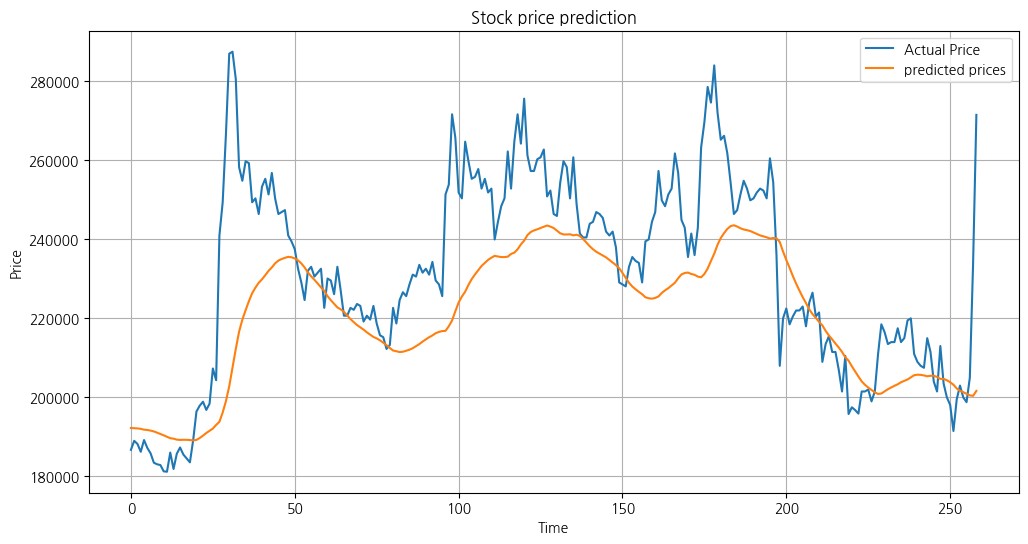

In [23]:
model.eval()                        # 모델 평가모드로 변경
with torch.no_grad():               # 그래디언트 계산 비활성화
    predicted = model(X_test_tensor).cpu().numpy()  # 테스트 데이터를 모델에 입력하여 예측 수행
# 예측값 스케일 복원
predicted_prices = scaler.inverse_transform(predicted)
real_prices = scaler.inverse_transform(y_test)
plt.figure(figsize=(12,6))
plt.plot(real_prices, label='Actual Price')
plt.plot(predicted_prices, label='predicted prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Stock price prediction')
plt.legend()
plt.grid()
plt.show()

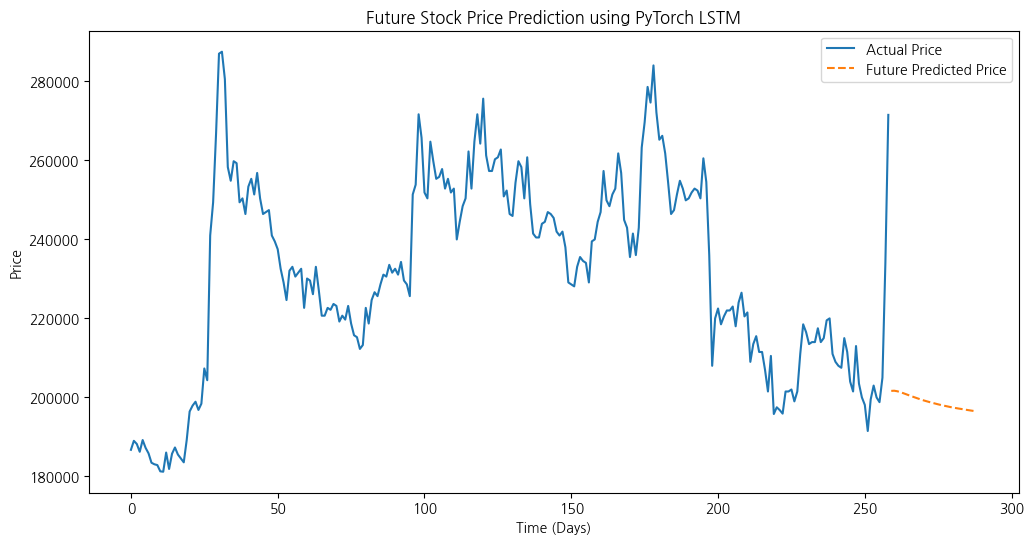

In [26]:
future_days =30
recent_sequence = X_test_tensor[-1].cpu().numpy().tolist()
predictions = []
model.eval()

with torch.no_grad():
    for _ in range(future_days):
        seq_tensor = torch.tensor(recent_sequence[-sequence_length:], dtype=torch.float32).unsqueeze(0).to(device)
        pred = model(seq_tensor).cpu().numpy()
        recent_sequence = np.append(recent_sequence, pred, axis=0)
        predictions.append(pred[0, 0])

# 스케일 역변환
predicted_future_prices = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# 1차원 배열로 변환
predicted_future_prices = predicted_future_prices.flatten()

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(real_prices, label='Actual Price')

# x축 인덱스 설정
plt.plot(range(len(real_prices), len(real_prices) + future_days),
         predicted_future_prices, label='Future Predicted Price', linestyle='--')

plt.title('Future Stock Price Prediction using PyTorch LSTM')
plt.xlabel('Time (Days)')
plt.ylabel('Price')
plt.legend()
plt.show()